## With 10 fold CV

Fold 1


c:\Users\knand\miniconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2


c:\Users\knand\miniconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 3


...

Fold 9


c:\Users\knand\miniconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 10


c:\Users\knand\miniconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Overall Classification Report:
                precision    recall  f1-score   support

Non-Premature       0.99      1.00      1.00       786
    Premature       0.99      0.95      0.97       114

     accuracy                           0.99       900
    macro avg       0.99      0.97      0.98       900
 weighted avg       0.99      0.99      0.99       900

Overall Accuracy: 0.9922
Overall Sensitivity: 0.9474
Overall Specificity: 0.9987


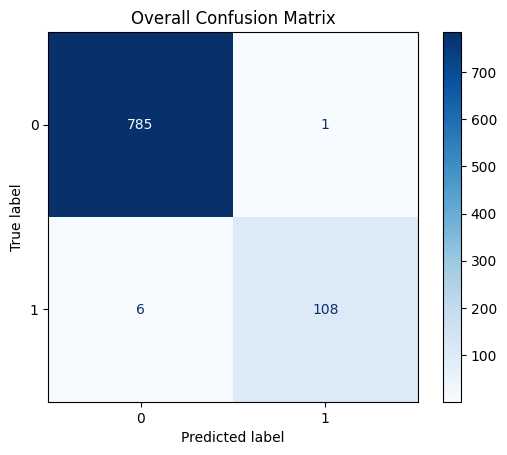

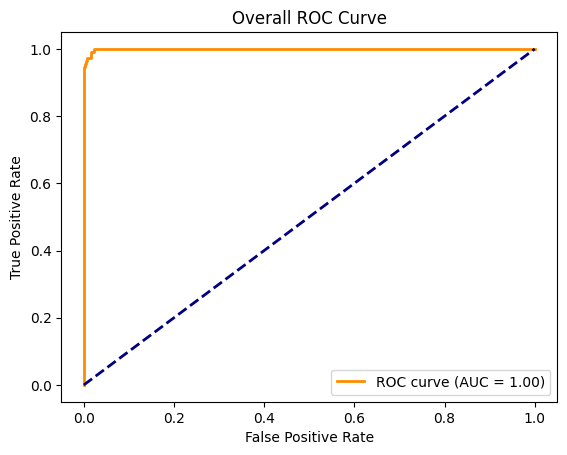

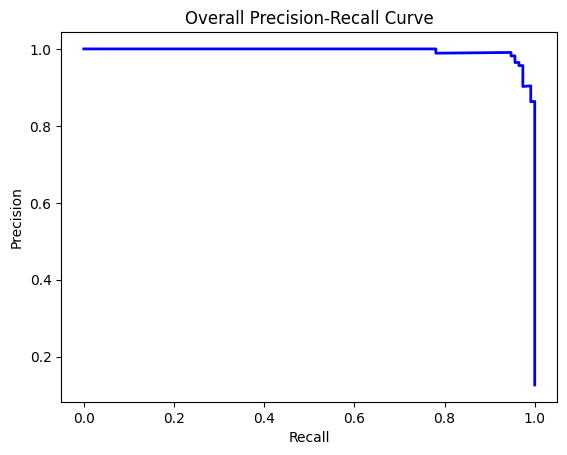

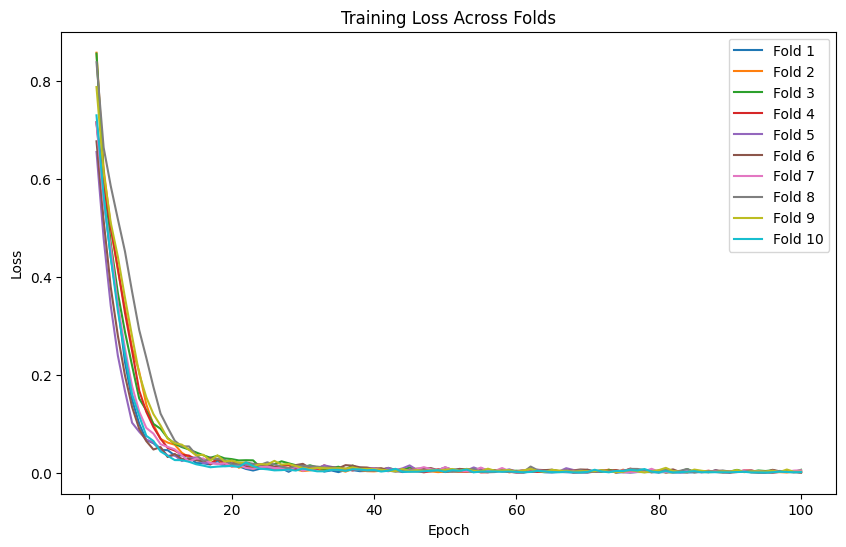

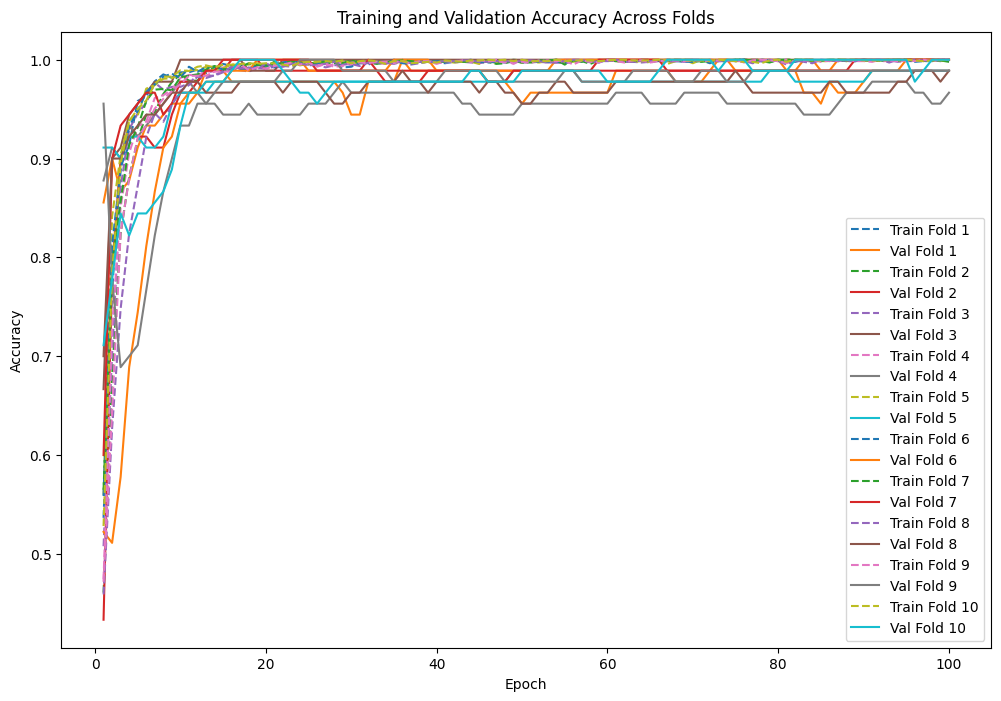

In [12]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, 
                             precision_recall_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
import torch.nn as nn

# Load and preprocess data
df = pd.read_csv("final_features_tpehg.csv")
X = df.drop(columns=["Premature", "RecID"])
y = df["Premature"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define GraphSAGE Model
class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
        self.bn = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.bn(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        x = self.fc(x)
        return x

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []
all_y_scores = []

# Tracking metrics
losses, train_accuracies, val_accuracies = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    print(f"Fold {fold+1}")

    # Train-validation split
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Apply ADASYN
    adasyn = ADASYN(sampling_strategy='minority', random_state=42)
    X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

    # Construct Graphs
    similarity_matrix_train = cosine_similarity(X_train_resampled)
    train_edge_index = torch.tensor(np.array(np.where(similarity_matrix_train > 0.85)), dtype=torch.long)
    train_data = Data(x=torch.tensor(X_train_resampled, dtype=torch.float), 
                      edge_index=train_edge_index, 
                      y=torch.tensor(y_train_resampled.to_numpy(), dtype=torch.long))

    similarity_matrix_val = cosine_similarity(X_val)
    val_edge_index = torch.tensor(np.array(np.where(similarity_matrix_val > 0.85)), dtype=torch.long)
    val_data = Data(x=torch.tensor(X_val, dtype=torch.float), 
                    edge_index=val_edge_index, 
                    y=torch.tensor(y_val.to_numpy(), dtype=torch.long))

    # Initialize model
    model = GraphSAGEModel(in_channels=X_train_resampled.shape[1], hidden_channels=32, out_channels=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    # Train model
    model.train()
    fold_losses, fold_train_acc, fold_val_acc = [], [], []
    
    for epoch in range(100):
        optimizer.zero_grad()
        out = model(train_data.x, train_data.edge_index)
        loss = criterion(out, train_data.y)
        loss.backward()
        optimizer.step()
        fold_losses.append(loss.item())
        
        train_predictions = out.argmax(dim=1)
        train_acc = accuracy_score(train_data.y.cpu(), train_predictions.cpu())
        fold_train_acc.append(train_acc)
        
        model.eval()
        with torch.no_grad():
            val_output = model(val_data.x, val_data.edge_index)
            val_predictions = val_output.argmax(dim=1)
            val_acc = accuracy_score(val_data.y.cpu(), val_predictions.cpu())
            fold_val_acc.append(val_acc)
        model.train()
    
    losses.append(fold_losses)
    train_accuracies.append(fold_train_acc)
    val_accuracies.append(fold_val_acc)
    
    all_y_true.extend(y_val.tolist())
    all_y_pred.extend(val_predictions.cpu().numpy())
    all_y_scores.extend(val_output.softmax(dim=1)[:, 1].cpu().numpy())

# Overall Metrics
overall_cm = confusion_matrix(all_y_true, all_y_pred)
overall_report = classification_report(all_y_true, all_y_pred, target_names=["Non-Premature", "Premature"])

overall_accuracy = accuracy_score(all_y_true, all_y_pred)
specificity = overall_cm[0, 0] / (overall_cm[0, 0] + overall_cm[0, 1])
sensitivity = overall_cm[1, 1] / (overall_cm[1, 0] + overall_cm[1, 1])

print("Overall Classification Report:\n", overall_report)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Sensitivity: {sensitivity:.4f}")
print(f"Overall Specificity: {specificity:.4f}")

ConfusionMatrixDisplay(confusion_matrix=overall_cm).plot(cmap=plt.cm.Blues)
plt.title("Overall Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Overall ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Overall Precision-Recall Curve")
plt.show()

# Loss Curve
plt.figure(figsize=(10, 6))
for i, fold_losses in enumerate(losses):
    plt.plot(range(1, 101), fold_losses, label=f"Fold {i+1}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Folds")
plt.legend()
plt.show()

# Accuracy Curve
plt.figure(figsize=(12, 8))
for i, (fold_train_acc, fold_val_acc) in enumerate(zip(train_accuracies, val_accuracies)):
    plt.plot(range(1, 101), fold_train_acc, label=f"Train Fold {i+1}", linestyle='--')
    plt.plot(range(1, 101), fold_val_acc, label=f"Val Fold {i+1}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Across Folds")
plt.legend()
plt.show()


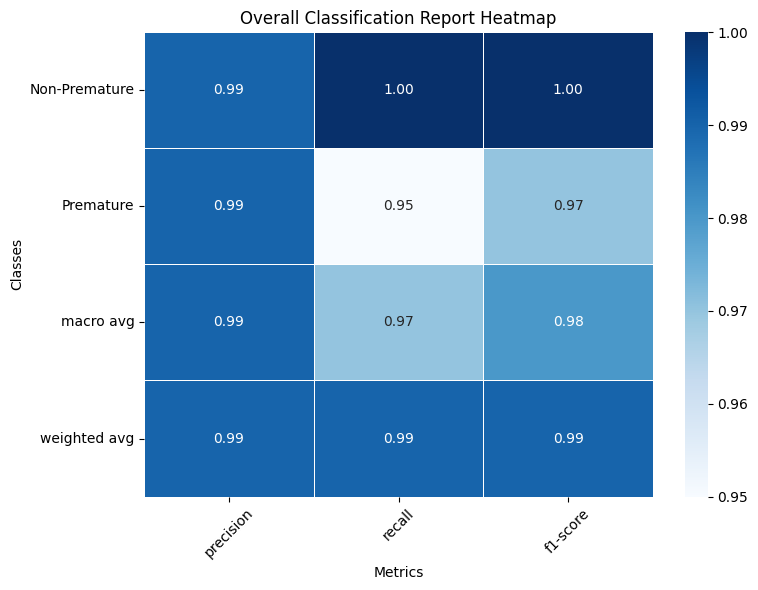

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Overall classification report data
report_data = {
    "Non-Premature": {"precision": 0.99, "recall": 1.00, "f1-score": 1.00},
    "Premature": {"precision": 0.99, "recall": 0.95, "f1-score": 0.97},
    "macro avg": {"precision": 0.99, "recall": 0.97, "f1-score": 0.98},
    "weighted avg": {"precision": 0.99, "recall": 0.99, "f1-score": 0.99},
}

# Convert to DataFrame
report_df = pd.DataFrame(report_data).transpose()

# Extract precision, recall, and f1-score
metrics_df = report_df[["precision", "recall", "f1-score"]]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(metrics_df, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

# Labels and title
plt.title("Overall Classification Report Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Show plot
plt.tight_layout()
plt.show()


In [5]:
torch.save(model.state_dict(), "gnn_preterm_model.pth")


## Without 10 fold CV

Epoch 10, Loss: 0.04750651866197586, Train Acc: 0.9865, Val Acc: 0.9667
Epoch 20, Loss: 0.012326601892709732, Train Acc: 0.9968, Val Acc: 0.9833
Epoch 30, Loss: 0.004229857586324215, Train Acc: 0.9984, Val Acc: 0.9889
Epoch 40, Loss: 0.010093036107718945, Train Acc: 0.9976, Val Acc: 0.9889
Epoch 50, Loss: 0.0033237708266824484, Train Acc: 0.9976, Val Acc: 0.9889
Epoch 60, Loss: 0.003033003071323037, Train Acc: 0.9984, Val Acc: 0.9833
Epoch 70, Loss: 0.0015722670359537005, Train Acc: 1.0000, Val Acc: 0.9778
Epoch 80, Loss: 0.0020583677105605602, Train Acc: 1.0000, Val Acc: 0.9833
Epoch 90, Loss: 0.0009327495936304331, Train Acc: 1.0000, Val Acc: 0.9833
Epoch 100, Loss: 0.005156883504241705, Train Acc: 0.9984, Val Acc: 0.9889


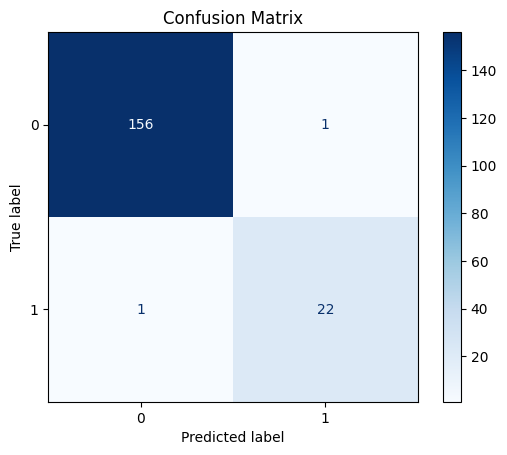

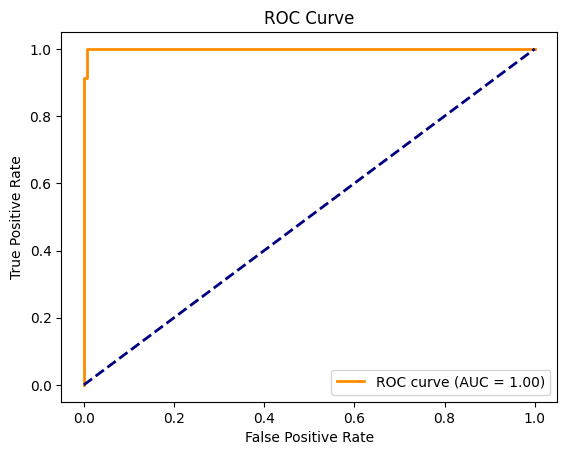

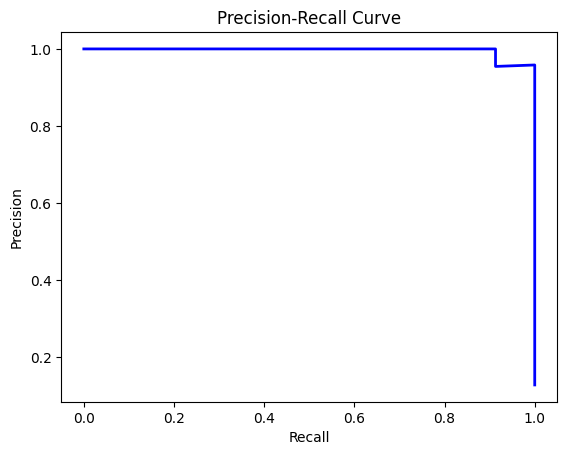

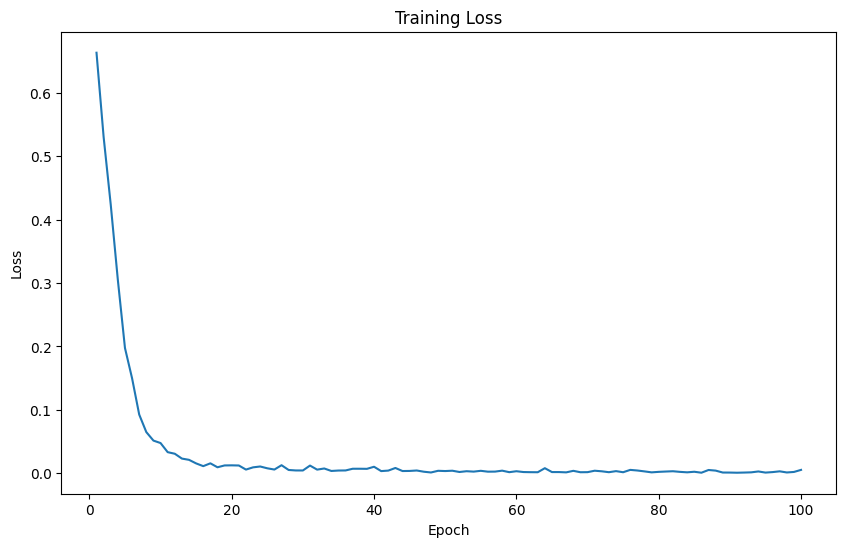

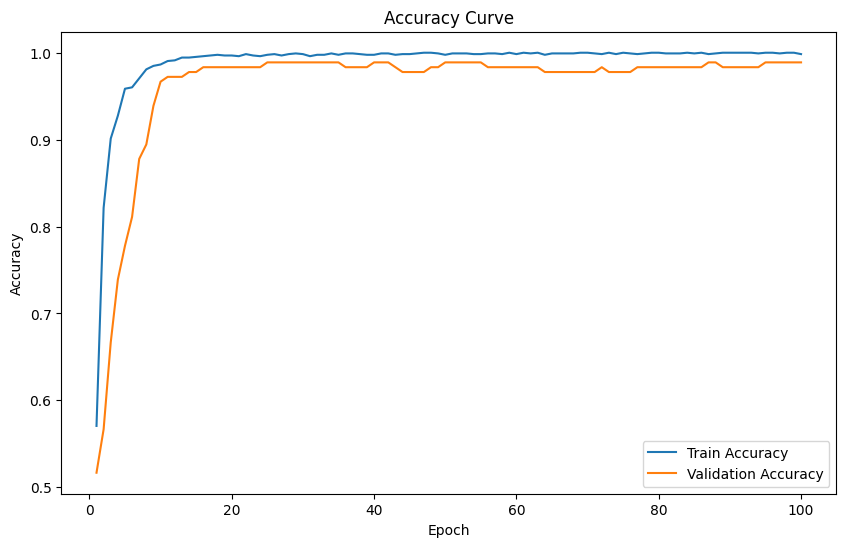

In [21]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# Load and preprocess data
df = pd.read_csv("final_features.csv")
X = df.drop(columns=["Premature", "RecID"])
y = df["Premature"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Apply ADASYN only on the training data
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

# Build train graph
similarity_matrix_train = cosine_similarity(X_train_resampled)
train_edge_index = torch.tensor(np.array(np.where(similarity_matrix_train > 0.85)), dtype=torch.long)
node_features_train = torch.tensor(X_train_resampled, dtype=torch.float)
labels_train = torch.tensor(y_train_resampled.to_numpy(), dtype=torch.long)
train_data = Data(x=node_features_train, edge_index=train_edge_index, y=labels_train)

# Build validation graph
similarity_matrix_val = cosine_similarity(X_val)
val_edge_index = torch.tensor(np.array(np.where(similarity_matrix_val > 0.85)), dtype=torch.long)
node_features_val = torch.tensor(X_val, dtype=torch.float)
labels_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)
val_data = Data(x=node_features_val, edge_index=val_edge_index, y=labels_val)

# Define GraphSAGE Model
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(dropout)
        self.bn = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.bn(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        x = self.fc(x)
        return x

# Define class weights
class_weights = torch.tensor([(len(y_train_resampled) - y_train_resampled.sum()) / len(y_train_resampled), 
                               y_train_resampled.sum() / len(y_train_resampled)], dtype=torch.float)

# Initialize model
model = GraphSAGEModel(in_channels=X_train_resampled.shape[1], hidden_channels=32, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# Train the model
model.train()
train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(100):  # Updated to 100 epochs
    optimizer.zero_grad()
    out = model(train_data.x, train_data.edge_index)
    loss = criterion(out, train_data.y)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Calculate training accuracy
    train_predictions = out.argmax(dim=1)
    train_acc = (train_predictions == train_data.y).sum().item() / len(train_data.y)
    train_accuracies.append(train_acc)

    # Validate the model
    model.eval()
    with torch.no_grad():
        val_output = model(val_data.x, val_data.edge_index)
        val_predictions = val_output.argmax(dim=1)
        val_acc = (val_predictions == val_data.y).sum().item() / len(val_data.y)
        val_accuracies.append(val_acc)
    model.train()  # Back to training mode

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item()}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, val_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
val_probs = val_output.softmax(dim=1)[:, 1].cpu().numpy()
fpr, tpr, _ = roc_curve(y_val, val_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, val_probs)
plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Accuracy Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), train_accuracies, label="Train Accuracy")
plt.plot(range(1, 101), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()


In [24]:
torch.save(model.state_dict(), "gnn_preterm_model_without cv.pth")


In [22]:
from sklearn.metrics import classification_report

# Classification Report
report = classification_report(y_val, val_predictions, target_names=["Non-Premature", "Premature"])
print("Classification Report:\n")
print(report)


Classification Report:

               precision    recall  f1-score   support

Non-Premature       0.99      0.99      0.99       157
    Premature       0.96      0.96      0.96        23

     accuracy                           0.99       180
    macro avg       0.98      0.98      0.98       180
 weighted avg       0.99      0.99      0.99       180



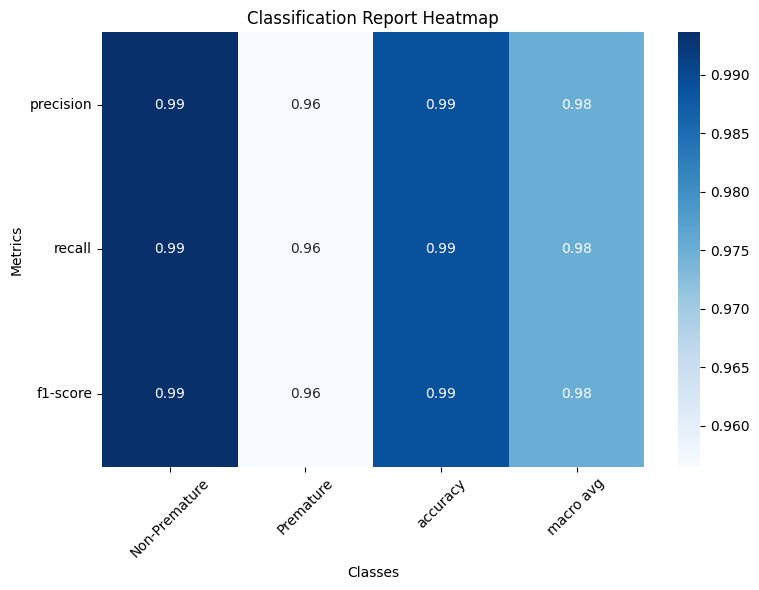

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

# Generate classification report as a dictionary
report_dict = classification_report(y_val, val_predictions, target_names=["Non-Premature", "Premature"], output_dict=True)

# Convert the dictionary into a dataframe for easier visualization
import pandas as pd
report_df = pd.DataFrame(report_dict).transpose()

# Drop support column for visualization (optional)
report_df = report_df.drop("support", axis=1)

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap="Blues", fmt=".2f")

# Add titles and labels
plt.title("Classification Report Heatmap")
plt.ylabel("Metrics")
plt.xlabel("Classes")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()
